# Tesseract OCR on Whole Image (Step-by-Step)

Target image: `Icdar2013\\Challenge2_Test_Task12_Images\\img_1.jpg`

## Step 1) Initialize Tesseract

In [ ]:
from pathlib import Path
import cv2
import pytesseract

In [ ]:

# Set this if Tesseract is not in PATH
pytesseract.pytesseract.tesseract_cmd = r"C:\\Program Files\\Tesseract-OCR\\tesseract.exe"

# OCR_LANG = "eng"
# OCR_CONFIG = "--oem 3 --psm 6"

## Step 2) Load the full image

In [2]:
# image_path = Path(r"Icdar2013\\Challenge2_Test_Task12_Images\\img_1.jpg")
image_path = Path(r"../../Icdar2013/Challenge2_Test_Task12_Images/img_1.jpg")

img_bgr = cv2.imread(str(image_path))


print(f"Step 2 complete: Loaded {image_path.resolve()}")
print(f"Image shape: {img_bgr.shape}")

Step 2 complete: Loaded D:\Handheld OCR Translator\Icdar2013\Challenge2_Test_Task12_Images\img_1.jpg
Image shape: (1280, 960, 3)


## Step 2.5) Try Tesseract on original image

In [ ]:
# detected = pytesseract.image_to_string(img_bgr, lang="eng", config="--oem 3 --psm 6")
detected = pytesseract.image_to_string(img_bgr, lang="eng")
print(f"OCR Result:\n{detected}")

OCR Result:
Tiredness
i vis 4 ce
couleesave™
your tire



## Step 3) Preprocess image

In [ ]:
gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
blur = cv2.GaussianBlur(gray, (3, 3), 0)
_, binary = cv2.threshold(blur, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

Step 3 complete: grayscale + blur + Otsu threshold applied.


(np.float64(-0.5), np.float64(959.5), np.float64(1279.5), np.float64(-0.5))

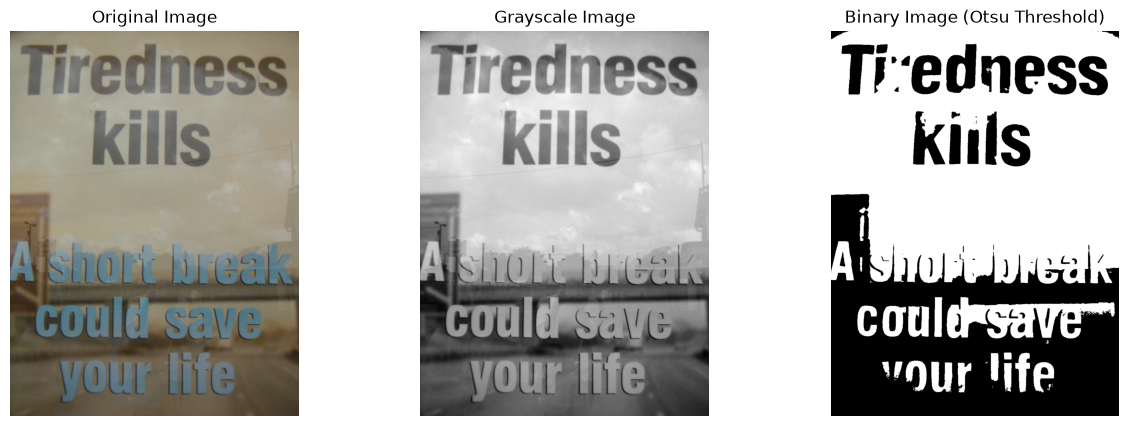

In [13]:
import matplotlib.pyplot as plt
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15, 5))

ax1.imshow(img_bgr)
ax1.set_title("Original Image")
ax1.axis("off")
ax2.imshow(gray, cmap="gray")
ax2.set_title("Grayscale Image")
ax2.axis("off")
ax3.imshow(binary, cmap="gray")
ax3.set_title("Binary Image (Otsu Threshold)")
ax3.axis("off")


## Step 4) Run Tesseract on whole image

In [ ]:
# deteced_preprocessed = pytesseract.image_to_string(binary, lang="eng", config="--oem 3 --psm 6")
# data = pytesseract.image_to_data(
#     binary,
#     lang="eng",
#     config="--oem 3 --psm 6",
#     output_type=pytesseract.Output.DATAFRAME
# )
deteced_preprocessed = pytesseract.image_to_string(binary, lang="eng")
print("Raw OCR preview:\n")
print(deteced_preprocessed[:1000])

Raw OCR preview:

Ti-edness
Kiils

e we fy ly ved

coulésave™
“our life



## Step 5) Post-process OCR text

In [11]:
result_preprocessed = result_preprocessed.strip()
print(result_preprocessed)

Ti-edness
Kiils

e we fy ly ved

coulésave™
“our life


In [7]:
df = data.copy()
df = df.dropna(subset=["text", "conf"])
df = df[df["text"].astype(str).str.strip() != ""]
df = df[df["conf"] >= 60]

clean_text = " ".join(df["text"].astype(str).tolist()).strip()
if not clean_text:
    clean_text = raw_text.strip()

print("Step 5 complete: text cleaned.")
print(clean_text[:1000])

Step 5 complete: text cleaned.
Ti-edness “our life


## Step 6) Save OCR text only

In [ ]:
out_dir = Path("outputs")
out_dir.mkdir(exist_ok=True)

ocr_out_path = out_dir / "img_1_ocr.txt"
ocr_out_path.write_text(clean_text, encoding="utf-8")

print("Step 6 complete: OCR text saved.")
print(f"- {ocr_out_path.resolve()}")


--- Final OCR Text ---

Ti-edness “our life

--- Translated Text ---

(Translation skipped: install deep-translator or check internet.)

Step 6 complete: files saved.
- D:\Handheld OCR Translator\handheld-ocr-translator\tesseract_tutorial\outputs\img_1_ocr.txt
- D:\Handheld OCR Translator\handheld-ocr-translator\tesseract_tutorial\outputs\img_1_translated.txt


## Step 7) Read ground truth

In [ ]:
gt_path = Path(r"Icdar2013\\Challenge2_Test_Task1_GT (1)\\gt_img_1.txt")


gt_text = gt_path.read_text(encoding="utf-8", errors="ignore").strip()
print("Step 7 complete: ground truth loaded.")
print(f"- {gt_path.resolve()}")

## Step 8) Calculate CER and WER

In [ ]:
def levenshtein_distance(seq1, seq2):
    n, m = len(seq1), len(seq2)
    if n == 0:
        return m
    if m == 0:
        return n

    dp = [[0] * (m + 1) for _ in range(n + 1)]
    for i in range(n + 1):
        dp[i][0] = i
    for j in range(m + 1):
        dp[0][j] = j

    for i in range(1, n + 1):
        for j in range(1, m + 1):
            cost = 0 if seq1[i - 1] == seq2[j - 1] else 1
            dp[i][j] = min(
                dp[i - 1][j] + 1,      # deletion
                dp[i][j - 1] + 1,      # insertion
                dp[i - 1][j - 1] + cost  # substitution
            )
    return dp[n][m]

pred_text = clean_text.strip()
gt_norm = gt_text.strip()

char_dist = levenshtein_distance(list(gt_norm), list(pred_text))
cer = char_dist / max(1, len(gt_norm))

gt_words = gt_norm.split()
pred_words = pred_text.split()
word_dist = levenshtein_distance(gt_words, pred_words)
wer = word_dist / max(1, len(gt_words))

metrics = {
    "cer": cer,
    "wer": wer,
    "char_distance": char_dist,
    "word_distance": word_dist,
    "gt_num_chars": len(gt_norm),
    "pred_num_chars": len(pred_text),
    "gt_num_words": len(gt_words),
    "pred_num_words": len(pred_words)
}

print("Step 8 complete: CER/WER calculated.")
print(metrics)

## Step 9) Save metrics to JSON

In [ ]:
import json

metrics_path = out_dir / "img_1_metrics.json"
metrics_path.write_text(json.dumps(metrics, indent=2), encoding="utf-8")

print("Step 9 complete: metrics saved.")
print(f"- {metrics_path.resolve()}")